In [1]:
# =========================
# 0) Setup
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

plt.rcParams["figure.dpi"] = 140

# =========================
# 1) Load data
# =========================
# If your file is named differently, change this:
path = "/content/amazon.csv"
df_raw = pd.read_csv(path)

print("Raw shape:", df_raw.shape)
df_raw.head()

Raw shape: (1465, 16)


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [2]:
# =========================
# 2) Cleaning functions
# =========================
def clean_price(series: pd.Series) -> pd.Series:
    # keeps digits and decimal; removes currency symbols, commas, spaces, etc.
    return pd.to_numeric(series.astype(str).str.replace(r"[^0-9.]", "", regex=True), errors="coerce")

def clean_percent(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series.astype(str).str.replace(r"[^0-9.]", "", regex=True), errors="coerce")

def clean_count(series: pd.Series) -> pd.Series:
    # rating_count can be like "1,79,691" (Indian commas), so keep digits only
    return pd.to_numeric(series.astype(str).str.replace(r"[^0-9]", "", regex=True), errors="coerce")

df = df_raw.copy()

# --- numeric conversions ---
df["discounted_price_inr"] = clean_price(df["discounted_price"])
df["actual_price_inr"] = clean_price(df["actual_price"])
df["discount_pct"] = clean_percent(df["discount_percentage"])

# rating might include text; extract numeric part
df["rating_num"] = pd.to_numeric(df["rating"].astype(str).str.extract(r"([0-9.]+)")[0], errors="coerce")

df["rating_count_num"] = clean_count(df["rating_count"])

# --- category normalization ---
df["main_category"] = df["category"].astype(str).str.split("|").str[0].str.strip()

# --- derived features ---
df["discount_amount_inr"] = df["actual_price_inr"] - df["discounted_price_inr"]
df["review_len"] = df["review_content"].astype(str).str.len()
df["title_len"] = df["review_title"].astype(str).str.len()

# --- drop duplicate reviews ---
df = df.drop_duplicates(subset=["product_id", "review_id"])

# --- fix inconsistent prices: if discounted > actual, swap ---
mask_swap = (
    df["discounted_price_inr"].notna()
    & df["actual_price_inr"].notna()
    & (df["discounted_price_inr"] > df["actual_price_inr"])
)
df.loc[mask_swap, ["discounted_price_inr", "actual_price_inr"]] = (
    df.loc[mask_swap, ["actual_price_inr", "discounted_price_inr"]].to_numpy()
)
df.loc[mask_swap, "discount_amount_inr"] = df["actual_price_inr"] - df["discounted_price_inr"]

# --- missing rating_count handling ---
df["rating_count_missing"] = df["rating_count_num"].isna()
df["rating_count_num"] = df["rating_count_num"].fillna(0)

print("Clean shape:", df.shape)
df.head()

Clean shape: (1361, 26)


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,...,discounted_price_inr,actual_price_inr,discount_pct,rating_num,rating_count_num,main_category,discount_amount_inr,review_len,title_len,rating_count_missing
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...",...,399.0,1099.0,64,4.2,24269.0,Computers&Accessories,700.0,483,124,False
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...",...,199.0,349.0,43,4.0,43994.0,Computers&Accessories,150.0,1186,181,False
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...",...,199.0,1899.0,90,3.9,7928.0,Computers&Accessories,1700.0,271,137,False
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...",...,329.0,699.0,53,4.2,94363.0,Computers&Accessories,370.0,443,140,False
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...",...,154.0,399.0,61,4.2,16905.0,Computers&Accessories,245.0,2451,138,False


In [3]:
# =========================
# 3) Category summary table (for stakeholders)
# =========================
def weighted_mean(values, weights):
    m = (~values.isna()) & (~weights.isna())
    if m.sum() == 0:
        return np.nan
    return np.average(values[m], weights=weights[m])

cat_summary = (
    df.groupby("main_category")
      .apply(lambda g: pd.Series({
          "products": g["product_id"].nunique(),
          "reviews": g["review_id"].nunique(),
          "total_rating_count": g["rating_count_num"].sum(),  # popularity proxy
          "avg_rating": g["rating_num"].mean(),
          "weighted_rating": weighted_mean(g["rating_num"], g["rating_count_num"] + 1),
          "avg_discount_pct": g["discount_pct"].mean(),
          "avg_discount_amount_inr": g["discount_amount_inr"].mean(),
          "median_discounted_price_inr": g["discounted_price_inr"].median(),
      }))
      .reset_index()
)
cat_summary["reviews_per_product"] = cat_summary["reviews"] / cat_summary["products"]
cat_summary = cat_summary.sort_values("total_rating_count", ascending=False)

cat_summary.head(10)

/tmp/ipykernel_180/1206853932.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,main_category,products,reviews,total_rating_count,avg_rating,weighted_rating,avg_discount_pct,avg_discount_amount_inr,median_discounted_price_inr,reviews_per_product
2,Electronics,490.0,386.0,14503100.0,4.077823,4.143043,50.127016,4191.969758,1399.0,0.787755
1,Computers&Accessories,375.0,323.0,6418812.0,4.152770,4.229044,53.453826,907.031451,399.0,0.861333
4,Home&Kitchen,448.0,448.0,2991069.0,4.040716,4.092291,40.120536,1831.458013,1199.0,1.000000
7,OfficeProducts,31.0,31.0,149675.0,4.309677,4.327157,12.354839,95.612903,178.0,1.000000
6,MusicalInstruments,2.0,2.0,88882.0,3.900000,3.954505,46.000000,709.000000,638.0,1.000000
8,Toys&Games,1.0,1.0,15867.0,4.300000,4.300000,0.000000,0.000000,150.0,1.000000
5,HomeImprovement,2.0,2.0,8566.0,4.250000,4.349323,57.500000,462.000000,337.0,1.000000
3,Health&PersonalCare,1.0,1.0,3663.0,4.000000,4.000000,53.000000,1001.000000,899.0,1.000000
0,Car&Motorbike,1.0,1.0,1118.0,3.800000,3.800000,42.000000,1661.000000,2339.0,1.000000


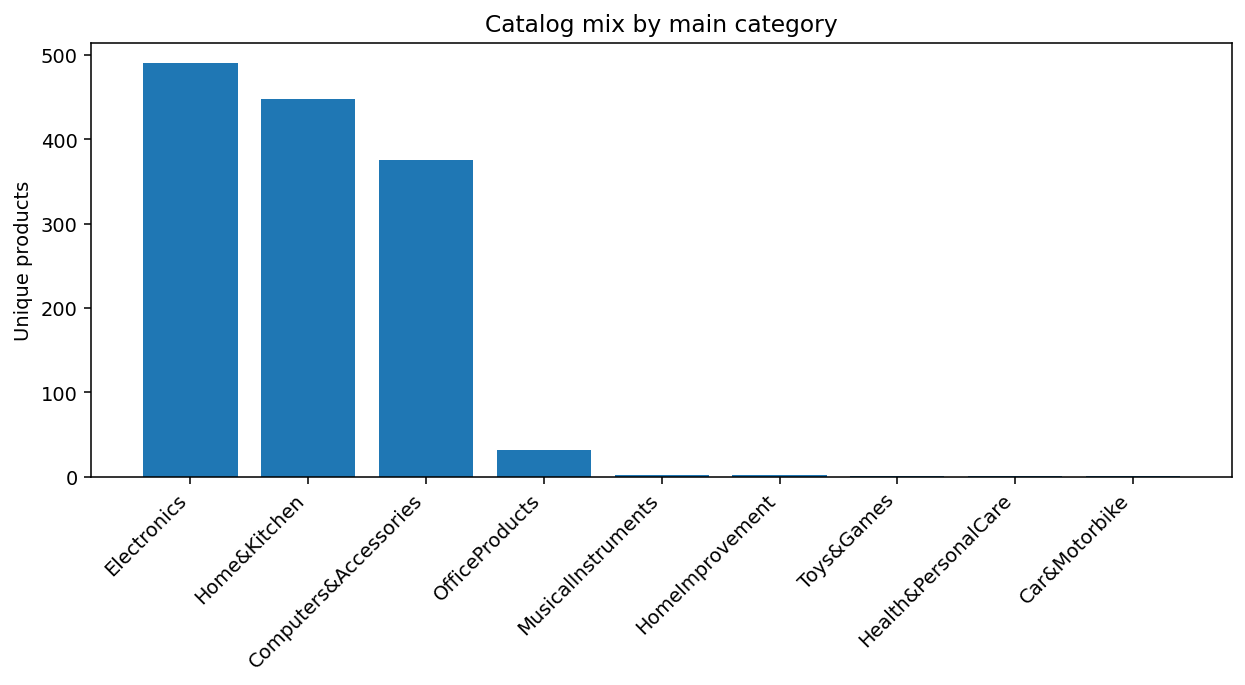

In [4]:
# =========================
# 4) Visualization 1: Catalog mix by category (unique products)
# =========================
cat_prod = cat_summary.sort_values("products", ascending=False)

plt.figure(figsize=(9,5))
plt.bar(cat_prod["main_category"], cat_prod["products"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Unique products")
plt.title("Catalog mix by main category")
plt.tight_layout()
plt.show()

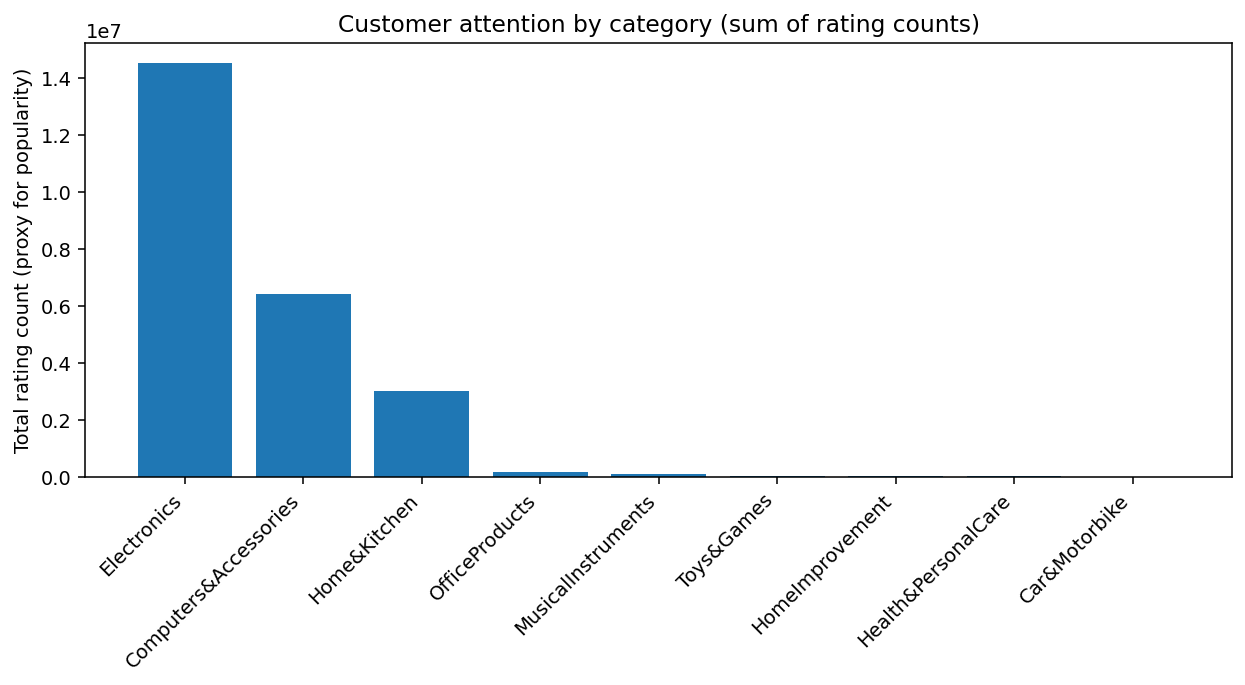

In [5]:
# =========================
# 5) Visualization 2: Customer attention by category (sum of rating counts)
# =========================
cat_attn = cat_summary.sort_values("total_rating_count", ascending=False)

plt.figure(figsize=(9,5))
plt.bar(cat_attn["main_category"], cat_attn["total_rating_count"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Total rating count (proxy for popularity)")
plt.title("Customer attention by category (sum of rating counts)")
plt.tight_layout()
plt.show()

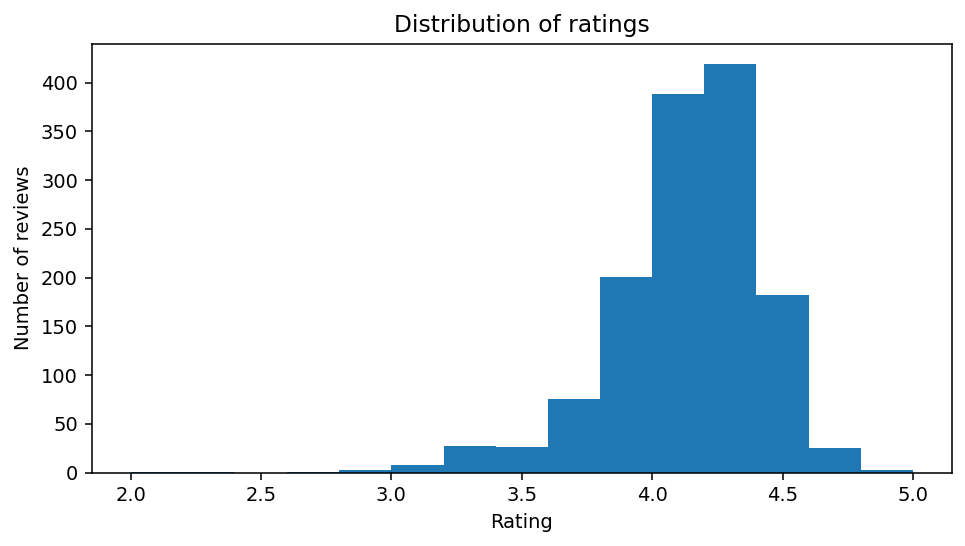

In [6]:
# =========================
# 6) Visualization 3: Ratings distribution
# =========================
plt.figure(figsize=(7,4))
plt.hist(df["rating_num"].dropna(), bins=15)
plt.xlabel("Rating")
plt.ylabel("Number of reviews")
plt.title("Distribution of ratings")
plt.tight_layout()
plt.show()

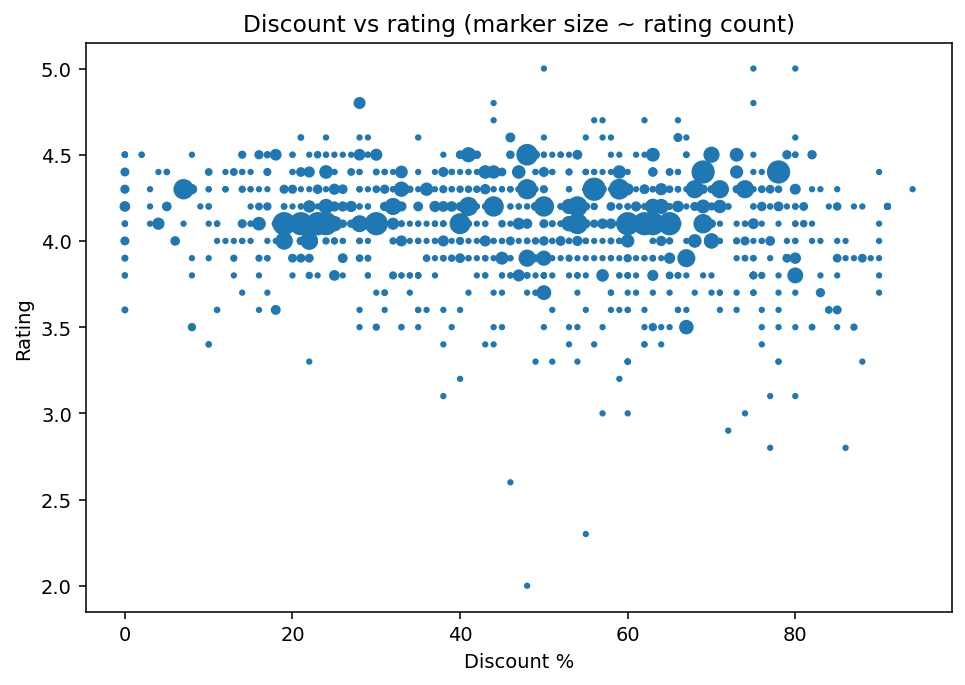

In [7]:
# =========================
# 7) Visualization 4: Discount vs Rating (scatter, size ~ rating_count)
# =========================
sample = df.sample(min(len(df), 1200), random_state=7)

plt.figure(figsize=(7,5))
plt.scatter(
    sample["discount_pct"],
    sample["rating_num"],
    s=np.clip(sample["rating_count_num"] / 2000, 5, 120)
)
plt.xlabel("Discount %")
plt.ylabel("Rating")
plt.title("Discount vs rating (marker size ~ rating count)")
plt.tight_layout()
plt.show()

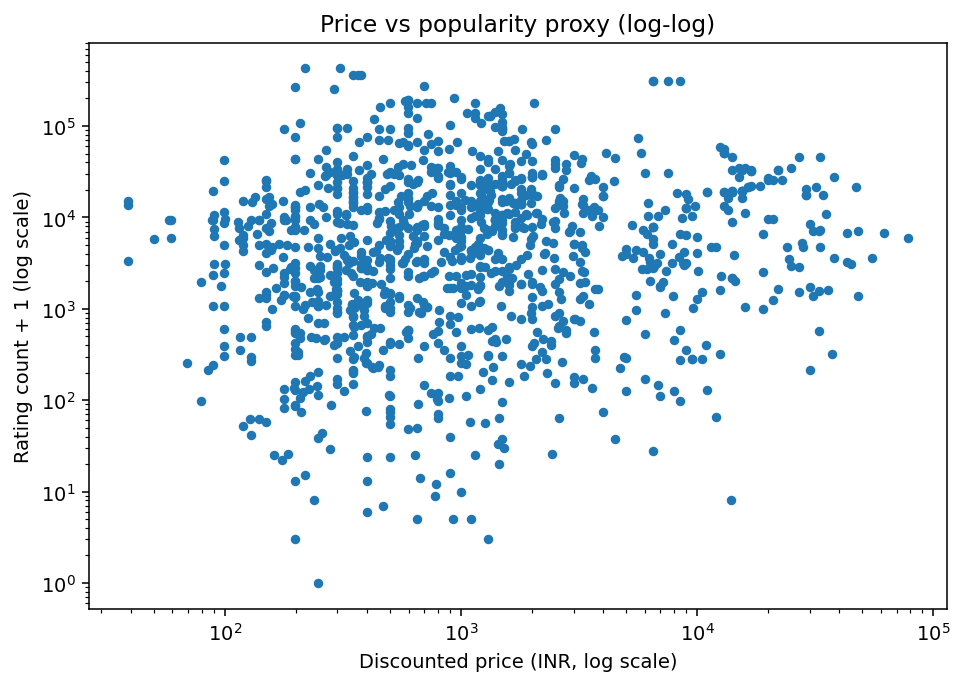

In [8]:
# =========================
# 8) Visualization 5: Price vs popularity proxy (log-log)
# =========================
plt.figure(figsize=(7,5))
plt.scatter(sample["discounted_price_inr"], sample["rating_count_num"] + 1, s=15)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Discounted price (INR, log scale)")
plt.ylabel("Rating count + 1 (log scale)")
plt.title("Price vs popularity proxy (log-log)")
plt.tight_layout()
plt.show()

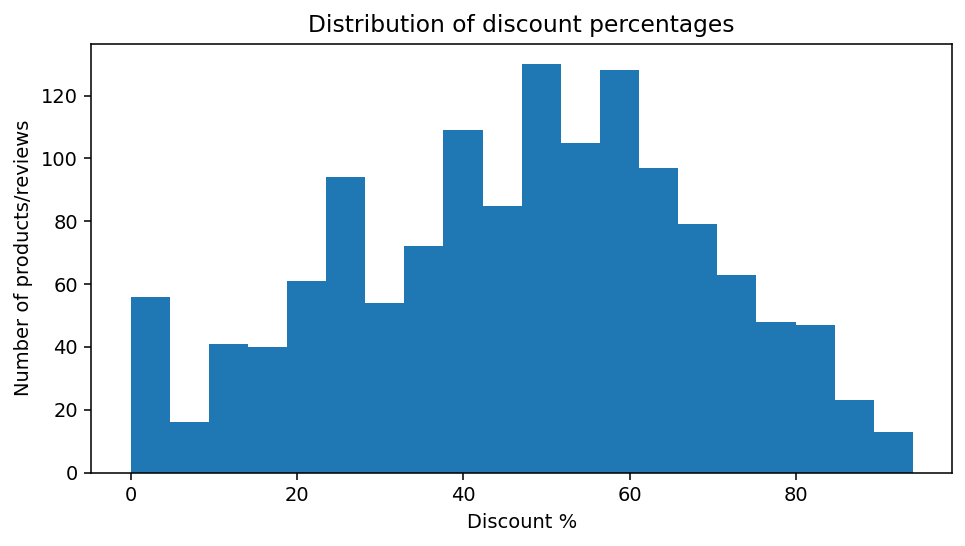

,discount_pct,rating_count_num,rating_num,discounted_price_inr
discount_pct,1.000000,-0.121945,-0.150867,-0.366451
rating_count_num,-0.121945,1.000000,0.189315,0.145678
rating_num,-0.150867,0.189315,1.000000,0.077546
discounted_price_inr,-0.366451,0.145678,0.077546,1.000000


In [9]:
# =========================
# 9) Visualization 6: Discount distribution + correlation table (Spearman)
# =========================
plt.figure(figsize=(7,4))
plt.hist(df["discount_pct"].dropna(), bins=20)
plt.xlabel("Discount %")
plt.ylabel("Number of products/reviews")
plt.title("Distribution of discount percentages")
plt.tight_layout()
plt.show()

spearman = df[["discount_pct","rating_count_num","rating_num","discounted_price_inr"]].corr(method="spearman")
spearman

In [10]:
# =========================
# 10) (Optional) Stars vs Risks tables (actionable for stakeholders)
# =========================
rating_cnt_threshold = df["rating_count_num"].quantile(0.90)

stars = (
    df[(df["rating_num"] >= 4.3) & (df["rating_count_num"] >= rating_cnt_threshold)]
    .sort_values(["rating_count_num","rating_num"], ascending=False)
    [["product_id","product_name","main_category","discounted_price_inr","discount_pct","rating_num","rating_count_num"]]
    .head(10)
)

risks = (
    df[(df["rating_num"] <= 3.8) & (df["rating_count_num"] >= rating_cnt_threshold)]
    .sort_values(["rating_count_num","rating_num"], ascending=[False, True])
    [["product_id","product_name","main_category","discounted_price_inr","discount_pct","rating_num","rating_count_num"]]
    .head(10)
)

print("=== Stars (high rating + high attention) ===")
display(stars)

print("=== Risks (low rating + high attention) ===")
display(risks)

=== Stars (high rating + high attention) ===


,product_id,product_name,main_category,discounted_price_inr,discount_pct,rating_num,rating_count_num
12,B07KSMBL2H,AmazonBasics Flexible Premium HDMI Cable (Blac...,Electronics,219.0,69,4.4,426973.0
47,B014I8SSD0,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...",Electronics,309.0,35,4.4,426973.0
65,B014I8SX4Y,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...",Electronics,309.0,78,4.4,426973.0
588,B005FYNT3G,SanDisk Cruzer Blade 32GB USB Flash Drive,Computers&Accessories,289.0,56,4.3,253105.0
864,B09X7DY7Q4,SanDisk Extreme SD UHS I 64GB Card for 4K Vide...,Electronics,939.0,48,4.5,205052.0
718,B01N6LU1VF,SanDisk Ultra Dual 64 GB USB 3.0 OTG Pen Drive...,Computers&Accessories,579.0,59,4.3,189104.0
337,B08HV83HL3,MI Power Bank 3i 20000mAh Lithium Polymer 18W ...,Electronics,2049.0,7,4.3,178912.0
356,B08HVL8QN3,"Mi 10000mAH Li-Polymer, Micro-USB and Type C I...",Electronics,1149.0,48,4.3,178912.0
440,B08HVJCW95,MI 10000mAh 3i Lithium Polymer Power Bank Dual...,Electronics,1149.0,48,4.3,178912.0
397,B09MT84WV5,Samsung EVO Plus 128GB microSDXC UHS-I U3 130M...,Electronics,1149.0,71,4.3,140036.0


=== Risks (low rating + high attention) ===


,product_id,product_name,main_category,discounted_price_inr,discount_pct,rating_num,rating_count_num
591,B08JQN8DGZ,boAt Airdopes 121v2 in-Ear True Wireless Earbu...,Electronics,1299.0,57,3.8,180998.0
656,B07LG59NPV,Boult Audio Probass Curve Bluetooth Wireless i...,Electronics,899.0,80,3.8,103052.0
716,B08FB2LNSZ,"JBL Tune 215BT, 16 Hrs Playtime with Quick Cha...",Electronics,1499.0,50,3.7,87798.0
415,B085W8CFLH,PTron Tangent Lite Bluetooth 5.0 Earphones wit...,Electronics,599.0,67,3.5,83996.0
680,B07L8KNP5F,ZEBRONICS Zeb-Thunder Bluetooth Wireless Over ...,Electronics,599.0,57,3.8,60026.0
1032,B01GFTEV5Y,Pigeon by Stovekraft Cruise 1800 watt Inductio...,Home&Kitchen,1699.0,47,3.8,54032.0
1045,B09X5C9VLK,Lifelong LLMG23 Power Pro 500-Watt Mixer Grind...,Home&Kitchen,1299.0,63,3.8,44050.0
847,B00N3XLDW0,ENVIE ECR-20 Charger for AA & AAA Rechargeable...,Electronics,299.0,25,3.8,40895.0


In [11]:
# =========================
# 11) Save cleaned data (optional)
# =========================
df.to_csv("/content/amazon_cleaned.csv", index=False)
print("Saved:", "/content/amazon_cleaned.csv")

Saved: /content/amazon_cleaned.csv
